### Baseline
Estableceremos nuestro modelo base como la media de la intensidad del incendio

In [1]:
import extraccion.minioFunctions as mf
from sklearn.model_selection import train_test_split, cross_validate # separación de datos y obtención de métricas
from sklearn.tree import DecisionTreeClassifier # modelo de árbol de decisión
from sklearn.linear_model import LogisticRegression # modelo de regresión logística
from sklearn.preprocessing import StandardScaler # normalización de nuestros datos
import matplotlib.pyplot as plt # graficar resultados
import seaborn as sns # para los boxplots
import pandas as pd # manipulación de los dataframes
import numpy as np  # operaciones con arrays

##### Carga de datos
Nos traemos nuestro dataframe final limpio y preprocesado

In [11]:
cliente = mf.crear_cliente()
df = mf.bajar_fichero(cliente, "grupo3/cleaned/final_date_transformado.parquet")

#Dividimos en variable explicativa y respuesta
df2 = df.copy()
y = df2["final"]
df2.drop(columns = ["final"], inplace = True)
X = df2

Dataframe importado correctamente


### Agrupamos variables por rango de valores
Para la hora de crear nuestros modelos, nos vendrá bien saber si para determinados modelos será necesario estandarizar.

C:\Users\PC\AppData\Local\Temp\ipykernel_12800\1606062731.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


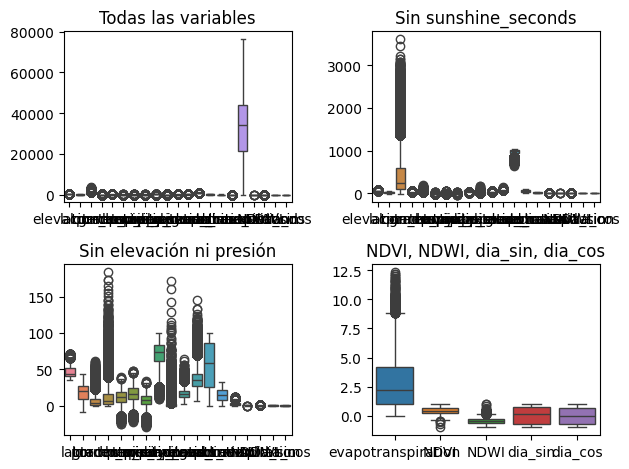

In [71]:
fig, ax = plt.subplots(nrows = 2, ncols = 2)
sns.boxplot(data = X, ax=ax[0,0])

X_vis = X.drop(columns=["sunshine_seconds"])
sns.boxplot(data = X_vis, ax=ax[0,1])

X_vis2 = X_vis.drop(columns=["elevacion_centro", "pressure_mean"])
sns.boxplot(data = X_vis2, ax=ax[1,0])

X_vis3 = X_vis2[["evapotranspiration", "NDVI", "NDWI", "dia_sin", "dia_cos"]]
sns.boxplot(data = X_vis3, ax=ax[1,1])

ax[0,0].set_title("Todas las variables")
ax[0,1].set_title("Sin sunshine_seconds")
ax[1,0].set_title("Sin elevación ni presión")
ax[1,1].set_title("NDVI, NDWI, dia_sin, dia_cos")

plt.tight_layout()

fig.show()

##### Conclusiones
Para los modelos que entrenemos que utilicen distancias entre datos (regresión logística, regresión lineal o knn), necesitaremos estandarizar los datos.

### Baseline riesgo incendios
Miramos la proporción de la clase mayoritaria con respecto a la de incendios

In [72]:
filtro = (y == 1)
no_incendios = len(y[filtro])
incendios = len(y[~filtro])

prop_incendios = no_incendios / (no_incendios + incendios)
prop_no_incendios = incendios / (no_incendios + incendios)

print(f"===== Incendios y no incendios ===== \n")
print(f"No incendios: {no_incendios}")
print(f"Incendios: {incendios}\n")

print(f"===== Proporción =====\n")
print(f"No incendios: {round(prop_no_incendios * 100, 2)}%")
print(f"Incendios: {round(prop_incendios * 100, 2)}%")

===== Incendios y no incendios ===== 

No incendios: 2684
Incendios: 68760

===== Proporción =====

No incendios: 96.24%
Incendios: 3.76%


##### Conclusiones
Nuestra clase mayoritaria es notablemente la de no incendios por lo que un accuracy muy alto no nos aporta gran información porque nuestro baseline tendría un accuracy del 96.24%

Necesitaremos que nuestro modelo de predicción de riesgo maximice la cantidad de incendios predichos como incendios (falsos negativos) y por ello tendremos que maximizar nuestro **RECALL**.

### Variables más significativas
Plantearemos dos modelos: uno que sí y otro que no estandarice los datos. Veremos las variables a las que se les da más peso 

##### División de los datos

In [12]:
X_train, X_div, y_train, y_div = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_div, y_div, test_size=0.5, random_state=42)

print(f"Tamaño conjunto de entrenamiento: {len(X_train)}")
print(f"Tamaño conjunto de prueba: {len(X_test)}")
print(f"Tamaño conjunto de validación: {len(X_val)}")

Tamaño conjunto de entrenamiento: 57155
Tamaño conjunto de prueba: 7145
Tamaño conjunto de validación: 7144


##### DecisionTreee

In [110]:
depths = [i for i in range(1, 50)]

train = []
test = []
for depth in depths:
  dt = DecisionTreeClassifier(criterion = "entropy",  random_state = 42, max_depth = depth, class_weight='balanced')
  dt.fit(X_train, y_train)
  scores = cross_validate(dt, X_train, y_train, cv = 10, return_train_score=True)
  train.append(scores['train_score'].mean())
  test.append(scores['test_score'].mean())

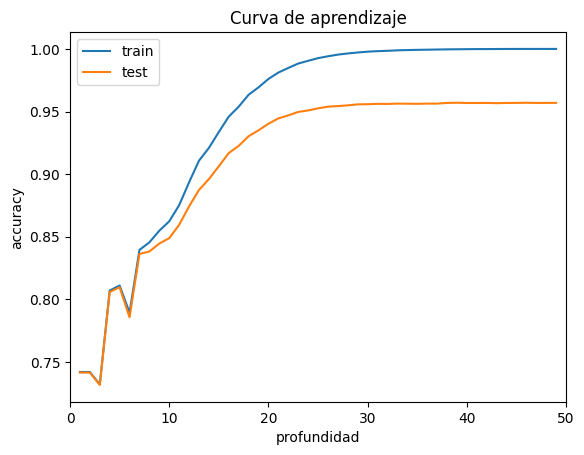

In [115]:
plt.plot(depths, train)
plt.plot(depths, test)
plt.title("Curva de aprendizaje")
plt.legend(["train", "test", "máximo"])
plt.xlim(0,50)
plt.xlabel("profundidad")
plt.ylabel("accuracy")

plt.show()

##### Conclusiones 
Con nuestras clases balanceadas, dándole el mismo peso a incendios y no incendios, nuestra profundidad que nos garantiza que no se produzca overfitting y que nuestro modelo no aprenda solamente de nuestros datos de entrenamiento está entorno entre 10 y 15. A partir de 20 nuestra gráfica converge.

In [122]:
dt = DecisionTreeClassifier(criterion = "entropy",  random_state = 42, max_depth = 12, class_weight="balanced")
dt.fit(X_train, y_train)

importancias = dt.feature_importances_
variables = X.columns

df_importancias = pd.DataFrame({'Variable': variables, 'Importancia': importancias}).sort_values(by = "Importancia", ascending = False, ignore_index=True)
df_importancias['Acumulado'] = df_importancias['Importancia'].cumsum()
df_importancias

,Variable,Importancia,Acumulado
0,humidity_mean,0.407421,0.407421
1,lon,0.111091,0.518512
2,lat,0.099917,0.618429
3,temp_min,0.056600,0.675029
4,NDVI,0.044942,0.719971
5,wind_gusts_max,0.034689,0.754660
6,cloud_cover,0.033590,0.788250
7,dia_sin,0.030542,0.818792
8,sunshine_seconds,0.028849,0.847641
9,elevacion_centro,0.026668,0.874309


##### Regresión logística
Empezamos normalizando los datos porque la regresión trabaja con distancias y nuestras variables se mueven en distintos rangos de valores, las normalizamos.

In [13]:
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
std_X_train_norm = np.sqrt(scaler.var_)

mean_X_train_norm = np.mean(X_train_norm)
print(f"La media es: {mean_X_train_norm}")
std_X_train_norm = np.std(X_train_norm)
print(f"La desviación estándar es: {std_X_train_norm}")

La media es: -7.48042541715271e-17
La desviación estándar es: 1.0


In [20]:
rl = LogisticRegression(random_state=42, max_iter=1000)
rl.fit(X_train_norm, y_train)

importancias = rl.coef_[0]
variables = X.columns

df_importancias = pd.DataFrame({'Variable': variables, 'Pesos': importancias}).sort_values(by = "Pesos", ascending = False, ignore_index=True)
df_importancias

,Variable,Pesos
0,temp_max,2.059200
1,pressure_mean,2.058845
2,elevacion_centro,1.541748
3,temp_min,0.784499
4,lat,0.591888
5,dia_cos,0.563782
6,wind_gusts_max,0.500230
7,evapotranspiration,0.413372
8,grados,0.280165
9,radiation,0.235401
